### Import Libraries and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load the dataset
try:
    df = pd.read_csv('telecommunications_churn.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: File not found.")

# Display basic info
print(f"Shape of dataset: {df.shape}")
print("\nFirst 5 rows:")
display(df.head())

print("\nData Info:")
print(df.info())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

Dataset loaded successfully.
Shape of dataset: (3333, 19)

First 5 rows:


,account_length,voice_mail_plan,voice_mail_messages,day_mins,evening_mins,night_mins,international_mins,customer_service_calls,international_plan,day_calls,day_charge,evening_calls,evening_charge,night_calls,night_charge,international_calls,international_charge,total_charge,churn
0,128,1,25,265.1,197.4,244.7,10.0,1,0,110,45.07,99,16.78,91,11.01,3,2.70,75.56,0
1,107,1,26,161.6,195.5,254.4,13.7,1,0,123,27.47,103,16.62,103,11.45,3,3.70,59.24,0
2,137,0,0,243.4,121.2,162.6,12.2,0,0,114,41.38,110,10.30,104,7.32,5,3.29,62.29,0
3,84,0,0,299.4,61.9,196.9,6.6,2,1,71,50.90,88,5.26,89,8.86,7,1.78,66.80,0
4,75,0,0,166.7,148.3,186.9,10.1,3,1,113,28.34,122,12.61,121,8.41,3,2.73,52.09,0



Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   account_length          3333 non-null   int64  
 1   voice_mail_plan         3333 non-null   int64  
 2   voice_mail_messages     3333 non-null   int64  
 3   day_mins                3333 non-null   float64
 4   evening_mins            3333 non-null   float64
 5   night_mins              3333 non-null   float64
 6   international_mins      3333 non-null   float64
 7   customer_service_calls  3333 non-null   int64  
 8   international_plan      3333 non-null   int64  
 9   day_calls               3333 non-null   int64  
 10  day_charge              3333 non-null   float64
 11  evening_calls           3333 non-null   int64  
 12  evening_charge          3333 non-null   float64
 13  night_calls             3333 non-null   int64  
 14  night_charge            3333

### Target Variable Analysis (Churn)

Churn Counts:
0    2850
1     483
Name: churn, dtype: int64
Overall Churn Rate: 14.49%


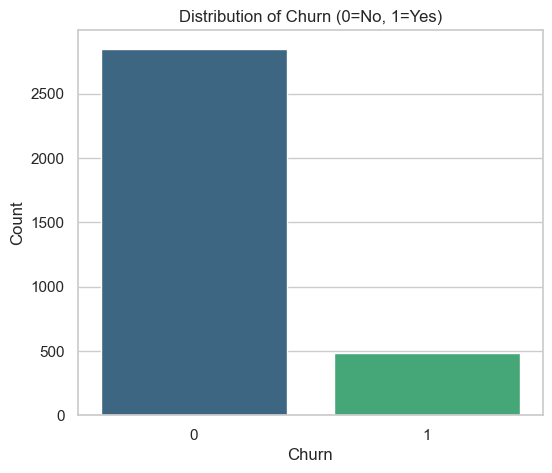

In [2]:
# Calculate Churn Rate
churn_counts = df['churn'].value_counts()
churn_rate = df['churn'].mean()

print(f"Churn Counts:\n{churn_counts}")
print(f"Overall Churn Rate: {churn_rate:.2%}")

# Visualize Churn Distribution
plt.figure(figsize=(6, 5))
sns.countplot(x='churn', data=df, palette='viridis')
plt.title('Distribution of Churn (0=No, 1=Yes)')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

### Categorical Features Analysis

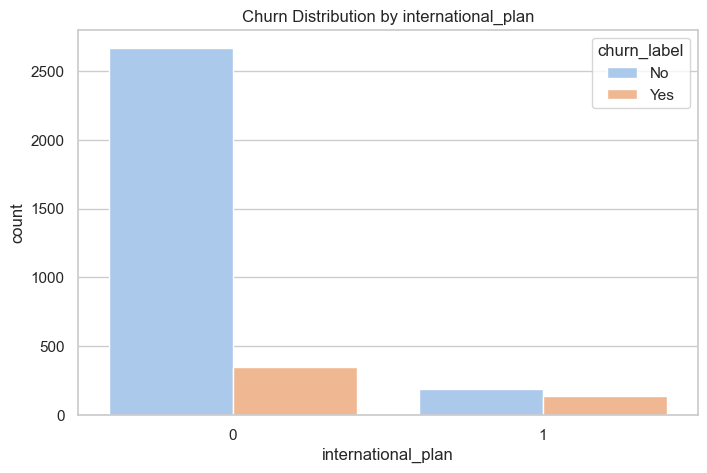


Churn Statistics for international_plan:
                    count      mean
international_plan                 
0                    3010  0.114950
1                     323  0.424149


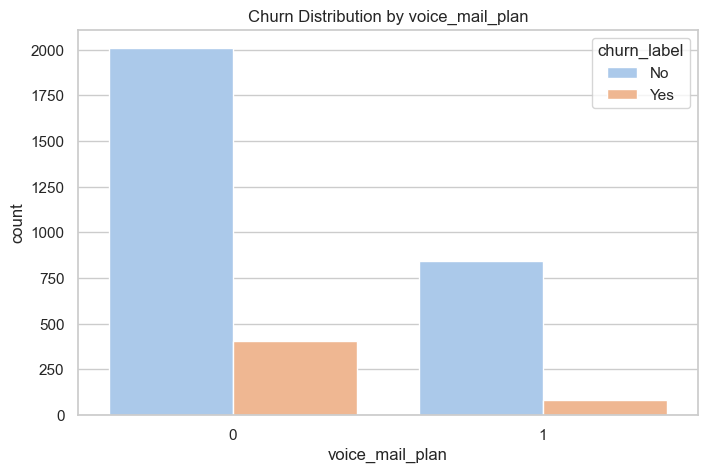


Churn Statistics for voice_mail_plan:
                 count      mean
voice_mail_plan                 
0                 2411  0.167151
1                  922  0.086768


In [4]:
# Create a temporary copy for plotting with string labels
df_plot = df.copy()
df_plot['churn_label'] = df['churn'].apply(lambda x: 'Yes' if x == 1 else 'No')

categorical_cols = ['international_plan', 'voice_mail_plan']

for col in categorical_cols:
    plt.figure(figsize=(8, 5))
    # Use 'churn_label' (string) instead of 'churn' (int) for hue
    sns.countplot(x=col, hue='churn_label', data=df_plot, palette='pastel')
    plt.title(f'Churn Distribution by {col}')
    plt.show()
    
    # Calculate churn rate by category (using original df for calculation)
    rate = df.groupby(col)['churn'].agg(['count', 'mean'])
    print(f"\nChurn Statistics for {col}:")
    print(rate)

### Numerical Feature Analysis (Customer Service Calls)

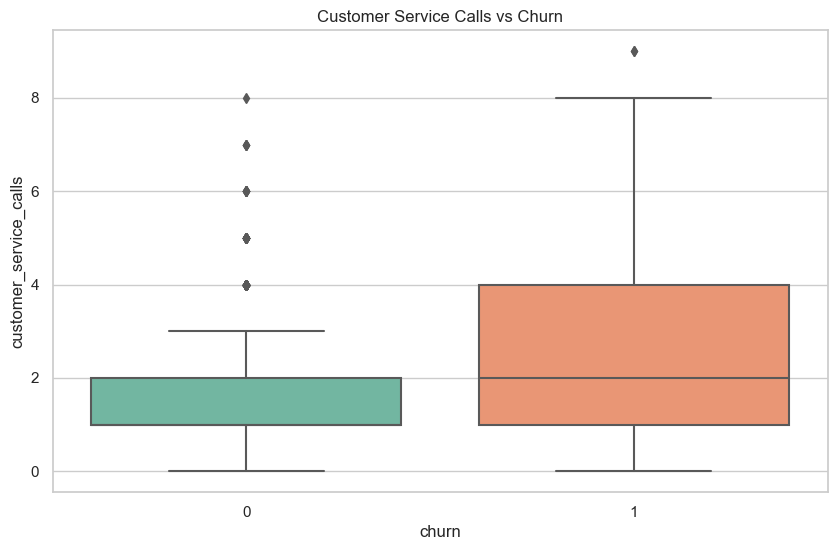


Churn Rate by Customer Service Calls:
   customer_service_calls  count      mean
0                       0    697  0.131994
1                       1   1181  0.103302
2                       2    759  0.114625
3                       3    429  0.102564
4                       4    166  0.457831
5                       5     66  0.606061
6                       6     22  0.636364
7                       7      9  0.555556
8                       8      2  0.500000
9                       9      2  1.000000


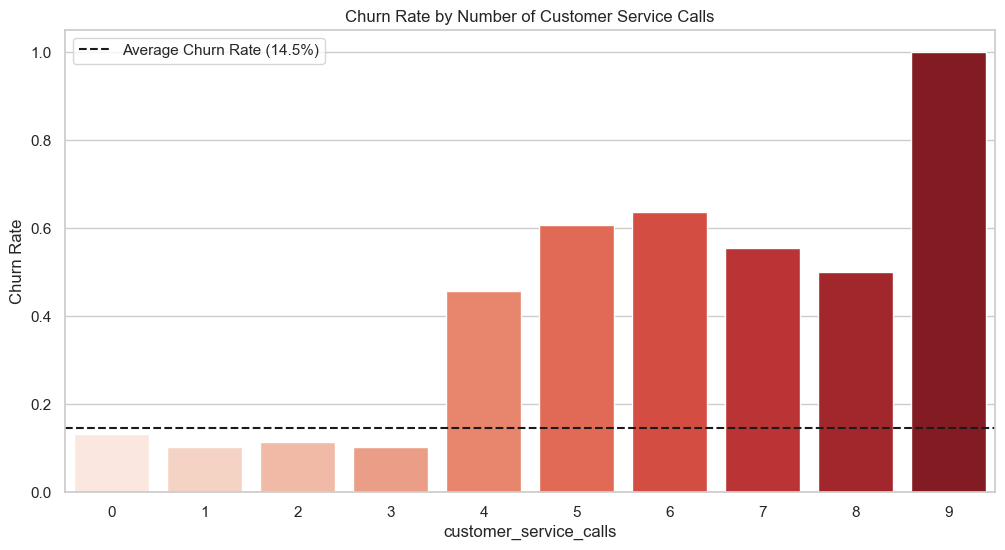

In [5]:
# Boxplot to see distribution
plt.figure(figsize=(10, 6))
sns.boxplot(x='churn', y='customer_service_calls', data=df, palette='Set2')
plt.title('Customer Service Calls vs Churn')
plt.show()

# Detailed Churn Rate by Number of Calls
calls_churn = df.groupby('customer_service_calls')['churn'].agg(['count', 'mean']).reset_index()
print("\nChurn Rate by Customer Service Calls:")
print(calls_churn)

# Visualizing the threshold
plt.figure(figsize=(12, 6))
sns.barplot(x='customer_service_calls', y='mean', data=calls_churn, palette='Reds')
plt.title('Churn Rate by Number of Customer Service Calls')
plt.ylabel('Churn Rate')
plt.axhline(y=churn_rate, color='k', linestyle='--', label='Average Churn Rate (14.5%)')
plt.legend()
plt.show()

### Correlation and Multicollinearity Analysis

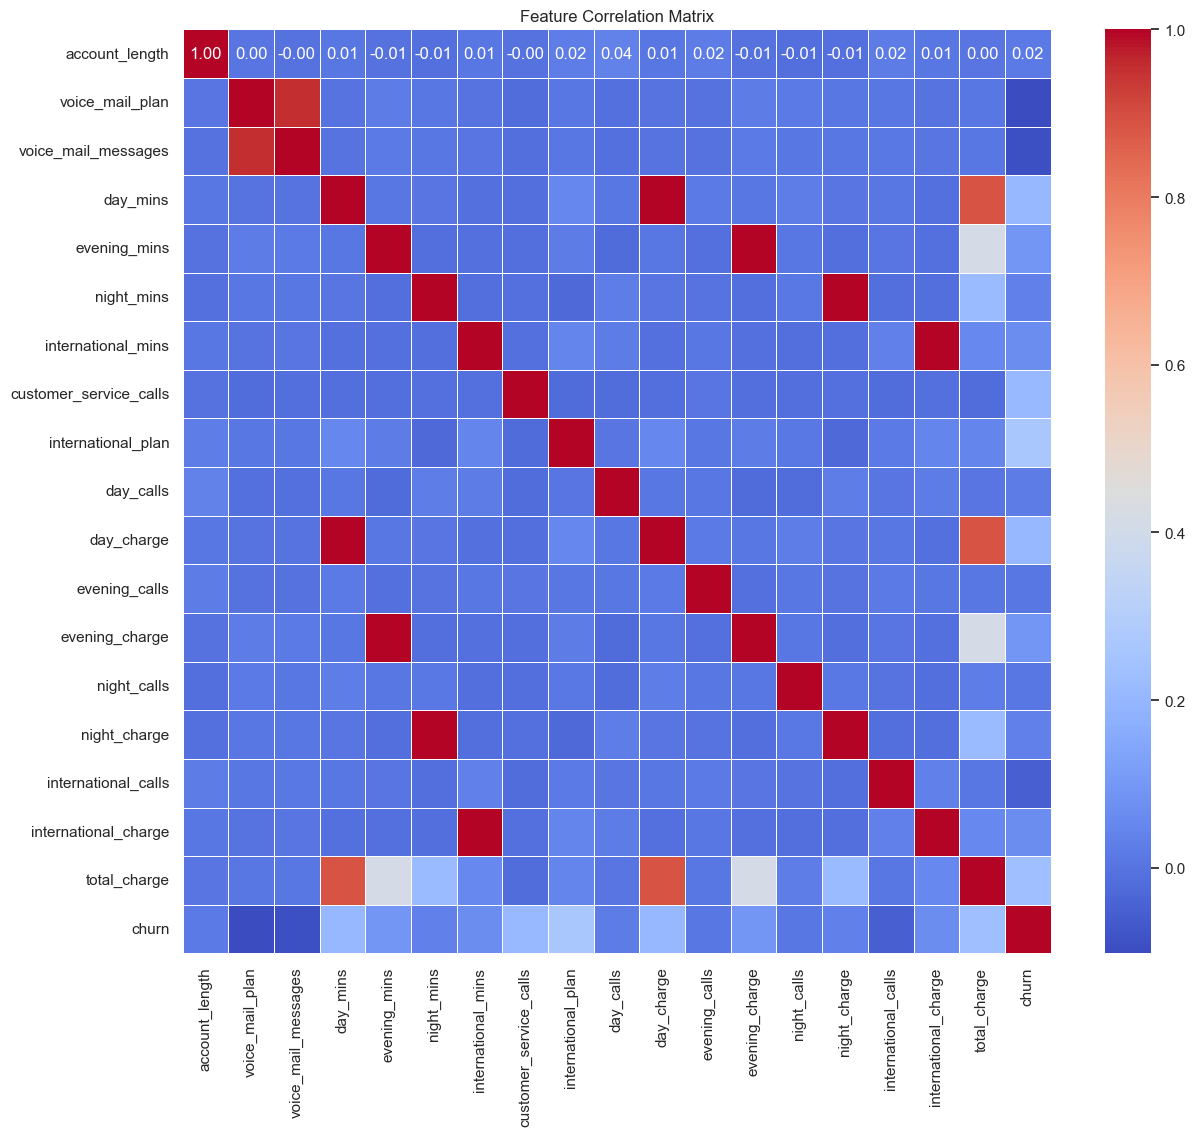


Correlation Check (Minutes vs Charges):
Day Mins vs Charge: 1.0000
Eve Mins vs Charge: 1.0000
Night Mins vs Charge: 1.0000
Intl Mins vs Charge: 1.0000


In [6]:
# Calculate correlation matrix
corr_matrix = df.corr()

# Plot heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

# Check specific high correlations
print("\nCorrelation Check (Minutes vs Charges):")
print(f"Day Mins vs Charge: {df['day_mins'].corr(df['day_charge']):.4f}")
print(f"Eve Mins vs Charge: {df['evening_mins'].corr(df['evening_charge']):.4f}")
print(f"Night Mins vs Charge: {df['night_mins'].corr(df['night_charge']):.4f}")
print(f"Intl Mins vs Charge: {df['international_mins'].corr(df['international_charge']):.4f}")

### Summary of Findings

In [7]:
print("="*40)
print("             EDA CONCLUSION              ")
print("="*40)
print("1. Churn Rate: ~14.5% (Imbalanced Dataset)")
print("2. Key Risk Factors:")
print("   - High Customer Service Calls (>3 calls)")
print("   - Having an International Plan (42% churn rate)")
print("3. Retention Factor:")
print("   - Having a Voice Mail Plan reduces churn risk.")
print("4. Data Engineering:")
print("   - 'Minutes' and 'Charges' are perfectly correlated.")
print("   - Recommendation: Drop 'Charge' columns to prevent multicollinearity.")
print("="*40)

             EDA CONCLUSION              
1. Churn Rate: ~14.5% (Imbalanced Dataset)
2. Key Risk Factors:
   - High Customer Service Calls (>3 calls)
   - Having an International Plan (42% churn rate)
3. Retention Factor:
   - Having a Voice Mail Plan reduces churn risk.
4. Data Engineering:
   - 'Minutes' and 'Charges' are perfectly correlated.
   - Recommendation: Drop 'Charge' columns to prevent multicollinearity.
